In [121]:
#%pip install pandas pyarrow
import pandas as pd
import pyarrow.parquet as pq

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


In [122]:
# Load in all stablecoins
dai = pd.read_parquet("../dse4101-project/clean_data/dai_clean.parquet")
pax = pd.read_parquet("../dse4101-project/clean_data/pax_clean.parquet")
usdc = pd.read_parquet("../dse4101-project/clean_data/usdc_clean.parquet")
usdt = pd.read_parquet("../dse4101-project/clean_data/usdt_clean.parquet")
ust = pd.read_parquet("../dse4101-project/clean_data/ust_clean.parquet")

In [123]:
print("DAI:", dai["depeg"].sum())
print("USDC:", usdc["depeg"].sum())
print("USDT:", usdt["depeg"].sum())
print("USDP:", pax["depeg"].sum())

ust_cut = ust[ust["timestamp"] <= "2022-05-11"]
print("ust:", ust_cut["depeg"].sum())

DAI: 32
USDC: 32
USDT: 29
USDP: 35
ust: 33


### Identifying optimal train/test split
We define a function below to help identify the optimal split for each stablecoin such that the number of depegs in each split is approximately equal

In [124]:

def split_equal_depegs(df, date_col="timestamp", target_col="depeg"):
    
    df = df.sort_values(date_col).reset_index(drop=True)
    df = df[df["timestamp"] <= "2024-12-31"]

    # cumulative number of depegs
    cumsum = df[target_col].cumsum()
    total = cumsum.iloc[-1]

    # find split where half depegs in each
    split_idx = (cumsum - total/2).abs().idxmin()

    train = df.iloc[:split_idx+1].copy()
    test  = df.iloc[split_idx+1:].copy()

    print("Split date:", df.loc[split_idx, date_col])
    print("Train depegs:", train[target_col].sum())
    print("Test  depegs:", test[target_col].sum())
    print("Train size:", len(train), "Test size:", len(test))
    print("------")

    return train, test


def split_by_date(df, split_date, date_col="timestamp"):
    df = df.sort_values(date_col).reset_index(drop=True)
    df = df[df[date_col] <= "2024-12-31"]
    train = df[df[date_col] <= split_date].copy()
    test  = df[df[date_col] >  split_date].copy()
    print(f"Split date: {split_date}")
    print(f"Train depegs: {train['depeg'].sum()}, Test depegs: {test['depeg'].sum()}")
    print(f"Train size: {len(train)}, Test size: {len(test)}")
    print("------")
    return train, test

In [125]:
MANUAL_SPLITS = {
    "USDC": "2022-06-30",
    "USDT": "2022-06-30",
    "DAI":  "2022-06-30",
}

splits = {}
# normal stablecoins
#for name, df in {
#    "DAI": dai,
#    "USDC": usdc,
 #   "USDT": usdt,
 #   "USDP": pax
#}.items():
    
#    print(name)
#    train, test = split_equal_depegs(df)
#    splits[name] = (train, test)

for name, df in {"DAI": dai, "USDC": usdc, "USDT": usdt, "USDP": pax}.items():
    print(name)
    if name in MANUAL_SPLITS:
        train, test = split_by_date(df, MANUAL_SPLITS[name])
    else:
        train, test = split_equal_depegs(df)
    splits[name] = (train, test)

# TerraUSD (only using period up till May 2022)
print("UST (TerraUSD)")
ust_cut = ust[ust["timestamp"] <= "2022-05-11"]
ust_train, ust_test = split_by_date(ust_cut, "2021-04-30")

splits["UST (TerraUSD)"] = (ust_train, ust_test)

DAI
Split date: 2022-06-30
Train depegs: 30, Test depegs: 2
Train size: 582, Test size: 915
------
USDC
Split date: 2022-06-30
Train depegs: 27, Test depegs: 5
Train size: 582, Test size: 915
------
USDT
Split date: 2022-06-30
Train depegs: 13, Test depegs: 14
Train size: 582, Test size: 915
------
USDP
Split date: 2023-07-25 23:59:59
Train depegs: 17
Test  depegs: 18
Train size: 973 Test size: 524
------
UST (TerraUSD)
Split date: 2021-04-30
Train depegs: 19, Test depegs: 14
Train size: 156, Test size: 376
------


### Summary table

In [126]:
summary = []

for k,(tr,te) in splits.items():
    summary.append({
        "coin": k,
        "train_start": tr.timestamp.min(),
        "train_end": tr.timestamp.max(),
        "test_start": te.timestamp.min(),
        "test_end": te.timestamp.max(),
        "train_depegs": tr.depeg.sum(),
        "test_depegs": te.depeg.sum()
    })

pd.DataFrame(summary)

,coin,train_start,train_end,test_start,test_end,train_depegs,test_depegs
0,DAI,2020-11-25 23:59:59,2022-06-29 23:59:59,2022-06-30 23:59:59,2024-12-30 23:59:59,30,2
1,USDC,2020-11-25 23:59:59,2022-06-29 23:59:59,2022-06-30 23:59:59,2024-12-30 23:59:59,27,5
2,USDT,2020-11-25 23:59:59,2022-06-29 23:59:59,2022-06-30 23:59:59,2024-12-30 23:59:59,13,14
3,USDP,2020-11-25 23:59:59,2023-07-25 23:59:59,2023-07-26 23:59:59,2024-12-30 23:59:59,17,18
4,UST (TerraUSD),2020-11-25 23:59:59,2021-04-29 23:59:59,2021-04-30 23:59:59,2022-05-10 23:59:59,19,14


### PCA

In [127]:
df_dai_final = pd.read_parquet("../dse4101-project/clean_data/dai_final.parquet")
df_pax_final = pd.read_parquet("../dse4101-project/clean_data/pax_final.parquet")
df_usdc_final = pd.read_parquet("../dse4101-project/clean_data/usdc_final.parquet")
df_usdt_final = pd.read_parquet("../dse4101-project/clean_data/usdt_final.parquet")
df_ust_final = pd.read_parquet("../dse4101-project/clean_data/ust_final.parquet")
# only use ust data up till May 2022
df_ust_final = df_ust_final[df_ust_final["timestamp"] <= "2022-05-11"]

In [128]:
#Prepare PCA input
def prepare_stablecoin_pca_df(df):

    drop_cols = [
        'depeg', 'timeOpen', 'timeClose', 'timeHigh', 'timeLow',
        'open', 'high', 'low', 'close', 'volume', 'marketCap', 'circulatingSupply',
        'depeg_future_1d', 'depeg_future_3d', 'depeg_future_5d', 'depeg_future_7d', 
        'depeg_future_14d', 'depeg_future_30d'
    ]

    pca_df = df.copy()

    # Drop only columns that actually exist
    pca_df = pca_df.drop(columns=[c for c in drop_cols if c in pca_df.columns], errors="ignore")
    
    pca_df['timestamp'] = pd.to_datetime(pca_df['timestamp']).dt.normalize()
    # Keep only timestamp, symbol and numeric feature columns
    pca_df = pca_df[['timestamp', 'symbol'] + [c for c in pca_df.columns if c not in ['timestamp', 'symbol'] and pd.api.types.is_numeric_dtype(pca_df[c])]]

    # Sort by time
    pca_df = pca_df.sort_values('timestamp').reset_index(drop=True)
    
    return pca_df

In [129]:
# Split each stablecoin into train/test
dai_train, dai_test = split_by_date(df_dai_final,  MANUAL_SPLITS["DAI"])
dai_train_pca = prepare_stablecoin_pca_df(dai_train)
dai_test_pca = prepare_stablecoin_pca_df(dai_test)

pax_train, pax_test = split_equal_depegs(df_pax_final)
pax_train_pca = prepare_stablecoin_pca_df(pax_train)
pax_test_pca = prepare_stablecoin_pca_df(pax_test)

usdc_train, usdc_test = split_by_date(df_usdc_final, MANUAL_SPLITS["USDC"])
usdc_train_pca = prepare_stablecoin_pca_df(usdc_train)
usdc_test_pca = prepare_stablecoin_pca_df(usdc_test)

usdt_train, usdt_test = split_by_date(df_usdt_final, MANUAL_SPLITS["USDT"])
usdt_train_pca = prepare_stablecoin_pca_df(usdt_train)
usdt_test_pca = prepare_stablecoin_pca_df(usdt_test)

ust_train, ust_test = split_by_date(df_ust_final, "2021-04-30")
ust_train_pca = prepare_stablecoin_pca_df(ust_train)
ust_test_pca = prepare_stablecoin_pca_df(ust_test)


Split date: 2022-06-30
Train depegs: 21, Test depegs: 2
Train size: 552, Test size: 915
------
Split date: 2023-07-25 23:59:59
Train depegs: 17
Test  depegs: 18
Train size: 943 Test size: 524
------
Split date: 2022-06-30
Train depegs: 27, Test depegs: 5
Train size: 552, Test size: 915
------
Split date: 2022-06-30
Train depegs: 12, Test depegs: 14
Train size: 552, Test size: 915
------
Split date: 2021-04-30
Train depegs: 19, Test depegs: 14
Train size: 126, Test size: 376
------


In [130]:
# run PCA
def fit_fixed_pca(train_df, test_df, n_components):
    numeric_cols = [c for c in train_df.columns if c not in ["timestamp", "symbol"]]

    # Imputer: fill NaNs with training mean
    imputer = SimpleImputer(strategy="mean")
    X_train_imputed = imputer.fit_transform(train_df[numeric_cols])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    
    pca = PCA(n_components=n_components)
    X_train_pcs = pca.fit_transform(X_train_scaled)
    
    # Train results
    train_pcs = pd.DataFrame(X_train_pcs, columns=[f"PC{i+1}" for i in range(X_train_pcs.shape[1])], index=train_df.index)
    
    # Test projection
    X_test_imputed = imputer.transform(test_df[numeric_cols])
    X_test_scaled = scaler.transform(X_test_imputed)
    test_pcs = pd.DataFrame(pca.transform(X_test_scaled), columns=train_pcs.columns, index=test_df.index)
    
    return {
        "loadings": pd.DataFrame(pca.components_.T, index=numeric_cols),
        "explained_variance": pca.explained_variance_ratio_,
        "pc_scores_train": train_pcs,
        "pc_scores_test": test_pcs
    }

In [131]:
# DAI
dai_pca_result = fit_fixed_pca(dai_train_pca, dai_test_pca, n_components=10)

# USDC
usdc_pca_result = fit_fixed_pca(usdc_train_pca, usdc_test_pca, n_components=10)

# UST
ust_pca_result = fit_fixed_pca(ust_train_pca, ust_test_pca, n_components=10)

# USDT
usdt_pca_result = fit_fixed_pca(usdt_train_pca, usdt_test_pca, n_components=10)

# USDP (PAX)
pax_pca_result = fit_fixed_pca(pax_train_pca, pax_test_pca, n_components=10)

In [132]:
# just save to csv so that i can see the full datasets

#dai_pca_result["pc_scores_train"].to_csv("dai_pca_train.csv", index=False)
#dai_pca_result["pc_scores_test"].to_csv("dai_pca_test.csv", index=False)
#dai_pca_result["loadings"].to_csv("dai_pca_loadings.csv")
#pd.Series(dai_pca_result["explained_variance"]).to_csv("dai_pca_explained_variance.csv")

### PC Selection
select all 10 for now, will change when we finalise stage 1 results

In [133]:
# ─────────────────────────────────────────────────────────────────────────────
# Stage 2C/2D: PC selections and training benchmark
# ─────────────────────────────────────────────────────────────────────────────

# Set these from Stage 1 findings 
PC_SELECTIONS = {
    "UST":  [0,2,9],   
    "USDC": [1,2,9],      
    "DAI":  [0,2,7],   
    "USDT": [2,3,6],      
    "USDP": [0,1,2],      
}

def compute_training_benchmark(pca_result, selected_pcs):
    """Stage 2D: compute mean and SD of selected PC scores on the training set."""
    train_scores = pca_result["pc_scores_train"]
    pc_cols = [f"PC{i+1}" for i in selected_pcs]
    mu    = train_scores[pc_cols].mean()
    sigma = train_scores[pc_cols].std(ddof=1)
    print("Training benchmark distribution:")
    for col in pc_cols:
        print(f"  {col}: mean={mu[col]:.4f}, sd={sigma[col]:.4f}")
    return {"mu": mu, "sigma": sigma, "pc_cols": pc_cols}



In [134]:

# ─────────────────────────────────────────────────────────────────────────────
# Stage 2E: test z-scores and anomaly signal
# ─────────────────────────────────────────────────────────────────────────────

def compute_test_zscores(pca_result, benchmark):
    """Project test PC scores into the training distribution → z-scores."""
    test_scores = pca_result["pc_scores_test"][benchmark["pc_cols"]]
    z_scores = (test_scores - benchmark["mu"]) / benchmark["sigma"]
    z_scores.columns = [f"z_{c}" for c in benchmark["pc_cols"]]
    return z_scores


def generate_signal(z_scores, threshold=3.0, consecutive_days=1):
    """
    Binary signal: 1 if ANY monitored PC exceeds ±threshold.
    consecutive_days > 1 requires that many consecutive triggers (noise filter).
    """
    any_exceed = (z_scores.abs() > threshold).any(axis=1).astype(int)
    if consecutive_days <= 1:
        return any_exceed
    rolling_sum = any_exceed.rolling(window=consecutive_days, min_periods=consecutive_days).sum()
    return (rolling_sum >= consecutive_days).astype(int)



In [135]:

# ─────────────────────────────────────────────────────────────────────────────
# Stage 2F: warning labels
# ─────────────────────────────────────────────────────────────────────────────

def build_warning_labels(test_df, signal, window_days=7,
                         date_col="timestamp", depeg_col="depeg"):
    """
    Label each test day 1 if it falls within `window_days` before a depeg
    (inclusive of the depeg day itself). Also records lead_days to next depeg.
    """
    df = test_df[[date_col, depeg_col]].copy().reset_index(drop=True)
    df["date"]   = pd.to_datetime(df[date_col]).dt.normalize()
    df["signal"] = signal.values
    df["depeg"]  = df[depeg_col].values

    depeg_dates = df.loc[df["depeg"] == 1, "date"].values

    def min_lead(d):
        future = depeg_dates[depeg_dates >= d]
        return (future[0] - d) / np.timedelta64(1, "D") if len(future) > 0 else np.nan

    df["lead_days"] = df["date"].apply(min_lead)
    df["label"]     = ((df["lead_days"] >= 0) & (df["lead_days"] <= window_days)).astype(int)
    return df[["date", "signal", "depeg", "label", "lead_days"]]



In [136]:

# ─────────────────────────────────────────────────────────────────────────────
# Stage 2G: predictive metrics
# ─────────────────────────────────────────────────────────────────────────────

def compute_metrics(labeled_df, coin=""):
    """Precision (key), recall, F1, specificity, avg lead time, false alarms/month."""
    y_true = labeled_df["label"].values
    y_pred = labeled_df["signal"].values

    TP = int(((y_pred == 1) & (y_true == 1)).sum())
    FP = int(((y_pred == 1) & (y_true == 0)).sum())
    TN = int(((y_pred == 0) & (y_true == 0)).sum())
    FN = int(((y_pred == 0) & (y_true == 1)).sum())

    precision   = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall      = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1          = (2 * precision * recall / (precision + recall)
                   if not (np.isnan(precision) or np.isnan(recall) or (precision + recall) == 0)
                   else np.nan)
    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan

    tp_mask      = (y_pred == 1) & (y_true == 1)
    avg_lead     = labeled_df.loc[tp_mask, "lead_days"].dropna().mean()
    fa_per_month = FP / (len(labeled_df) / 30.44)

    print(f"\n{'='*50}")
    print(f"  {coin} — Predictive Metrics")
    print(f"{'='*50}")
    print(f"  Confusion: TP={TP}, FP={FP}, TN={TN}, FN={FN}")
    print(f"  Precision  (key): {precision:.3f}")
    print(f"  Recall:           {recall:.3f}")
    print(f"  F1:               {f1:.3f}")
    print(f"  Specificity:      {specificity:.3f}")
    print(f"  Avg lead time:    {avg_lead:.1f} days before depeg")
    print(f"  False alarms:     {fa_per_month:.2f} / month")

    return {
        "coin": coin,
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "specificity": round(specificity, 4),
        "avg_lead_days": round(avg_lead, 2) if not np.isnan(avg_lead) else np.nan,
        "fa_per_month": round(fa_per_month, 2),
        "n_test_days": len(labeled_df),
    }



In [137]:
def run_oos_evaluation(coin, pca_result, test_df, selected_pcs=None,
                       threshold=3.0, consecutive_days=1, window_days=7):
    if selected_pcs is None:
        selected_pcs = PC_SELECTIONS.get(coin, [0])

    # Combined signal across all selected PCs
    benchmark  = compute_training_benchmark(pca_result, selected_pcs)
    z_scores   = compute_test_zscores(pca_result, benchmark)
    signal     = generate_signal(z_scores, threshold=threshold, consecutive_days=consecutive_days)
    labeled_df = build_warning_labels(test_df, signal, window_days=window_days)
    metrics    = compute_metrics(labeled_df, coin=coin)

    # Per-PC breakdown
    pc_rows = []
    for pc_idx in selected_pcs:
        bm   = compute_training_benchmark(pca_result, [pc_idx])
        z    = compute_test_zscores(pca_result, bm)
        sig  = generate_signal(z, threshold=threshold, consecutive_days=consecutive_days)
        ldf  = build_warning_labels(test_df, sig, window_days=window_days)
        m    = compute_metrics(ldf, coin=f"{coin} PC{pc_idx+1}")
        m["pc"] = f"PC{pc_idx+1}"
        pc_rows.append(m)
    pc_breakdown = pd.DataFrame(pc_rows)[["pc","precision","recall","f1","specificity","avg_lead_days","fa_per_month","TP","FP","TN","FN"]]

    return {"metrics": metrics, "labeled_df": labeled_df,
            "z_scores": z_scores, "benchmark": benchmark, "signal": signal,
            "pc_breakdown": pc_breakdown}


def sensitivity_sweep(coin, pca_result, test_df, selected_pcs,
                      thresholds=[1.5, 2.0, 2.5, 3.0],
                      windows=[5, 7, 10], consecutive_days=1):
    rows = []
    for thr in thresholds:
        for win in windows:
            bm  = compute_training_benchmark(pca_result, selected_pcs)
            z   = compute_test_zscores(pca_result, bm)
            sig = generate_signal(z, threshold=thr, consecutive_days=consecutive_days)
            ldf = build_warning_labels(test_df, sig, window_days=win)
            m   = compute_metrics(ldf, coin=coin)
            m["threshold"] = thr; m["window"] = win
            rows.append(m)
    cols = ["coin","threshold","window","precision","recall","f1",
            "specificity","avg_lead_days","fa_per_month","TP","FP","TN","FN"]
    return pd.DataFrame(rows)[cols].sort_values(["precision","recall"], ascending=False)

In [138]:

# ─────────────────────────────────────────────────────────────────────────────
# Plot: z-score timeline with depeg markers and warning windows
# ─────────────────────────────────────────────────────────────────────────────

def plot_signal_timeline(result, coin, threshold=3.0, figsize=(14, 4)):
    labeled_df = result["labeled_df"]
    z_scores   = result["z_scores"]
    dates      = labeled_df["date"].values

    fig, axes = plt.subplots(len(z_scores.columns), 1, figsize=figsize, sharex=True)
    if len(z_scores.columns) == 1:
        axes = [axes]

    for ax, col in zip(axes, z_scores.columns):
        ax.plot(dates, z_scores[col].values, lw=1.2, color="steelblue", label=col)
        ax.axhline( threshold, color="darkorange", ls="--", lw=1, label=f"+{threshold}σ")
        ax.axhline(-threshold, color="darkorange", ls="--", lw=1)

        # shade pre-depeg warning windows
        in_window = labeled_df["label"].values == 1
        starts = np.where(np.diff(np.concatenate([[0], in_window.astype(int), [0]])) == 1)[0]
        ends   = np.where(np.diff(np.concatenate([[0], in_window.astype(int), [0]])) == -1)[0]
        for s, e in zip(starts, ends):
            ax.axvspan(dates[s], dates[min(e, len(dates)-1)], alpha=0.12, color="salmon")

        # depeg day markers
        for dd in labeled_df.loc[labeled_df["depeg"] == 1, "date"].values:
            ax.axvline(dd, color="crimson", lw=1.5, alpha=0.85)

        ax.set_ylabel(col, fontsize=9)
        ax.legend(loc="upper left", fontsize=8)
        ax.grid(True, alpha=0.25)

    axes[-1].set_xlabel("Date")
    fig.suptitle(f"{coin} — OOS Signal (crimson=depeg, shading=warning window)",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()



Training benchmark distribution:
  PC1: mean=-0.0000, sd=2.3907
  PC3: mean=-0.0000, sd=1.7707
  PC10: mean=0.0000, sd=0.7181

  UST — Predictive Metrics
  Confusion: TP=9, FP=2, TN=318, FN=47
  Precision  (key): 0.818
  Recall:           0.161
  F1:               0.269
  Specificity:      0.994
  Avg lead time:    1.8 days before depeg
  False alarms:     0.16 / month
Training benchmark distribution:
  PC1: mean=-0.0000, sd=2.3907

  UST PC1 — Predictive Metrics
  Confusion: TP=6, FP=0, TN=320, FN=50
  Precision  (key): 1.000
  Recall:           0.107
  F1:               0.194
  Specificity:      1.000
  Avg lead time:    1.7 days before depeg
  False alarms:     0.00 / month
Training benchmark distribution:
  PC3: mean=-0.0000, sd=1.7707

  UST PC3 — Predictive Metrics
  Confusion: TP=5, FP=2, TN=318, FN=51
  Precision  (key): 0.714
  Recall:           0.089
  F1:               0.159
  Specificity:      0.994
  Avg lead time:    2.0 days before depeg
  False alarms:     0.16 / month


,coin,threshold,window,precision,recall,f1,specificity,avg_lead_days,fa_per_month,TP,FP,TN,FN
9,UST,3.0,5,0.8182,0.2045,0.3273,0.9940,1.78,0.16,9,2,330,35
10,UST,3.0,7,0.8182,0.1607,0.2687,0.9938,1.78,0.16,9,2,318,47
11,UST,3.0,10,0.8182,0.1216,0.2118,0.9934,1.78,0.16,9,2,300,65
8,UST,2.5,10,0.3091,0.2297,0.2636,0.8742,3.59,3.08,17,38,264,57
5,UST,2.0,10,0.2593,0.3784,0.3077,0.7351,4.04,6.48,28,80,222,46
7,UST,2.5,7,0.2545,0.2500,0.2523,0.8719,2.43,3.32,14,41,279,42
6,UST,2.5,5,0.2182,0.2727,0.2424,0.8705,1.75,3.48,12,43,289,32
2,UST,1.5,10,0.2048,0.6892,0.3158,0.3444,4.45,16.03,51,198,104,23
4,UST,2.0,7,0.2037,0.3929,0.2683,0.7312,2.68,6.96,22,86,234,34
3,UST,2.0,5,0.1667,0.4091,0.2368,0.7289,1.83,7.29,18,90,242,26


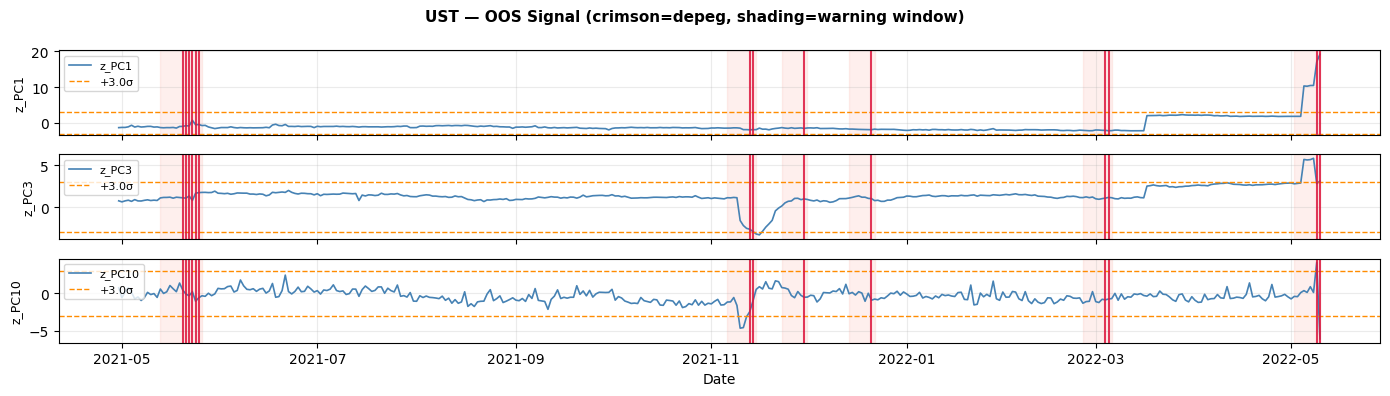

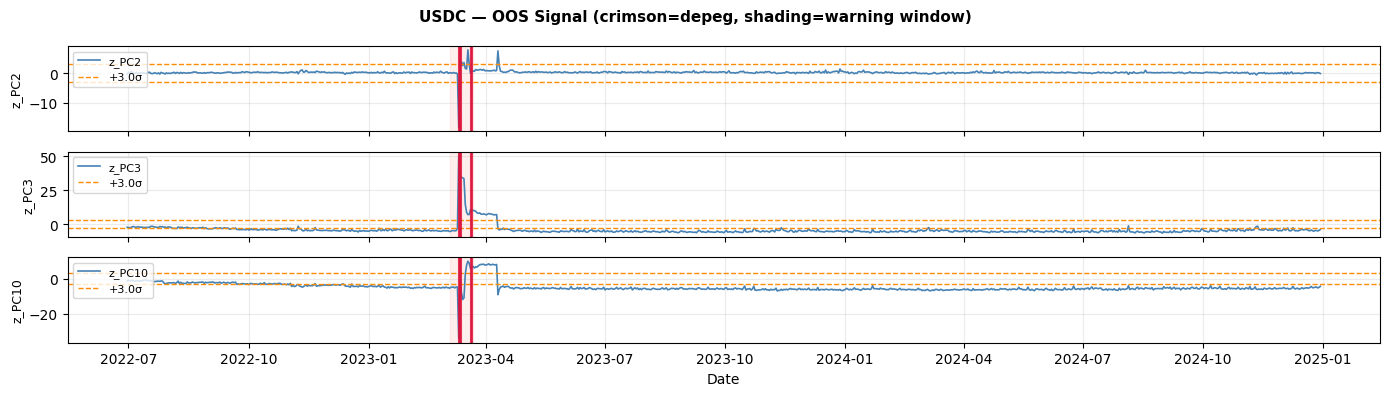

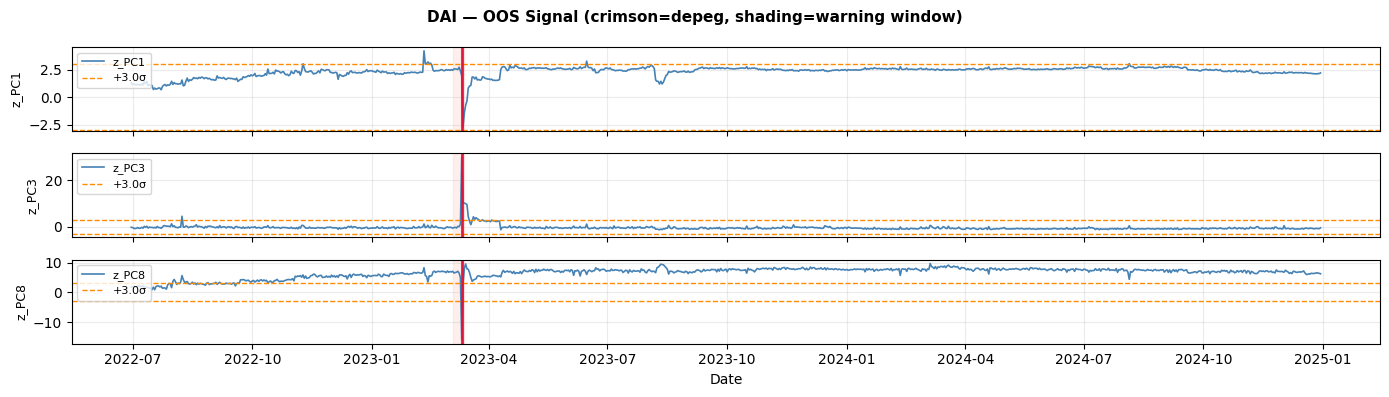

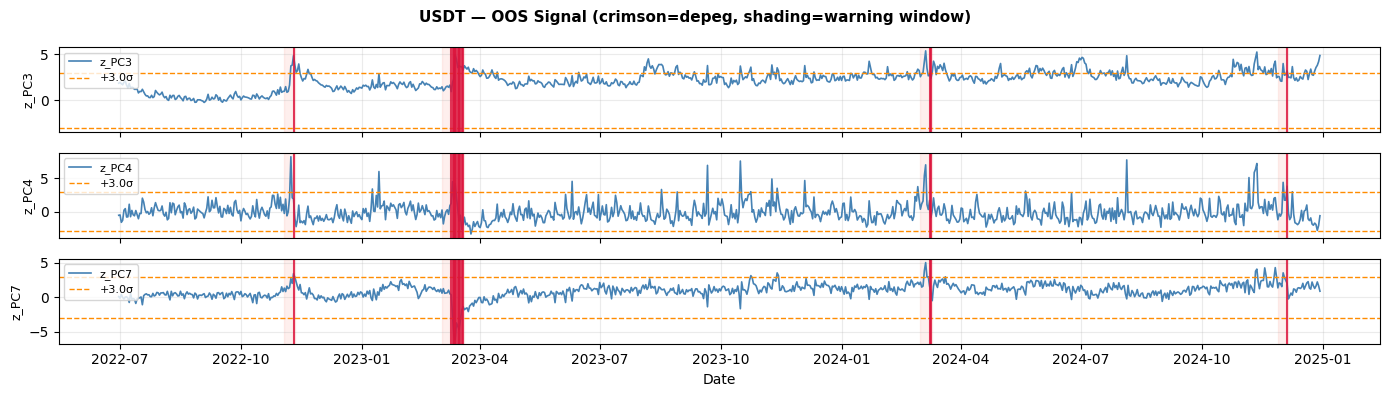

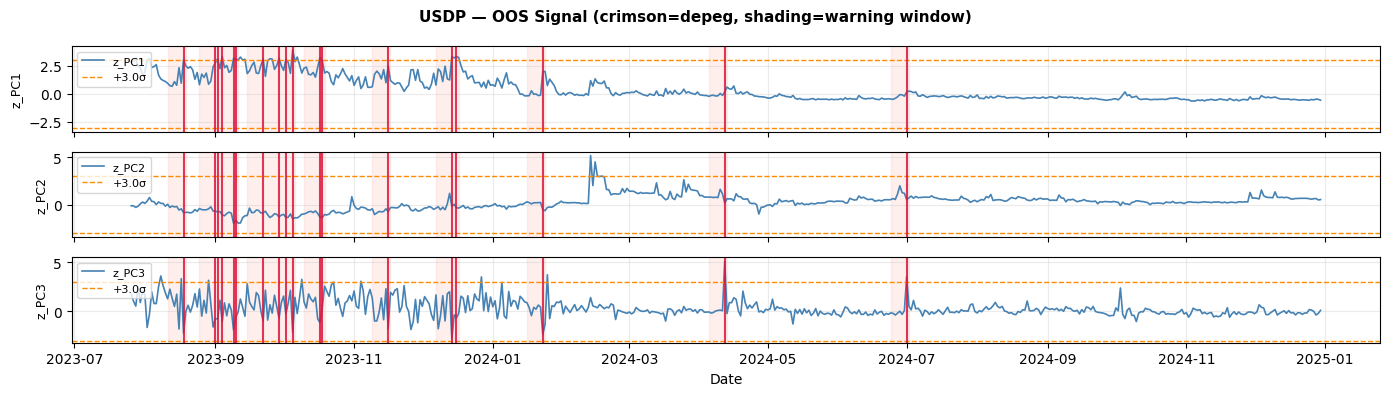

In [139]:

# ─────────────────────────────────────────────────────────────────────────────
# Usage
# ─────────────────────────────────────────────────────────────────────────────

# Run all coins (assumes *_pca_result and *_test variables exist from Stage 2B)
results = {}
for coin, pca_res, test in [
    ("UST",  ust_pca_result,  ust_test),
    ("USDC", usdc_pca_result, usdc_test),
    ("DAI",  dai_pca_result,  dai_test),
    ("USDT", usdt_pca_result, usdt_test),
    ("USDP", pax_pca_result,  pax_test),
]:
    results[coin] = run_oos_evaluation(coin, pca_res, test, threshold=3.0, window_days=7)

# Sensitivity sweep for UST
ust_sweep = sensitivity_sweep("UST", ust_pca_result, ust_test, PC_SELECTIONS["UST"])
display(ust_sweep.head(12))

# Plots
for coin, res in results.items():
    plot_signal_timeline(res, coin=coin)

In [140]:
# Combined summary table (one row per coin)
print("\n=== Combined signal (all selected PCs) ===")
display(pd.DataFrame([r["metrics"] for r in results.values()]).set_index("coin"))

# Per-PC breakdown (one row per PC per coin)
print("\n=== Per-PC breakdown ===")
for coin, res in results.items():
    print(f"\n{coin}")
    display(res["pc_breakdown"].set_index("pc"))


=== Combined signal (all selected PCs) ===


,TP,FP,TN,FN,precision,recall,f1,specificity,avg_lead_days,fa_per_month,n_test_days
coin,,,,,,,,,,,
UST,9,2,318,47,0.8182,0.1607,0.2687,0.9938,1.78,0.16,376
USDC,18,832,65,0,0.0212,1.0000,0.0415,0.0725,2.72,27.68,915
DAI,9,847,59,0,0.0105,1.0000,0.0208,0.0651,3.11,28.18,915
USDT,18,148,725,24,0.1084,0.4286,0.1731,0.8305,1.11,4.92,915
USDP,19,15,412,78,0.5588,0.1959,0.2901,0.9649,0.63,0.87,524



=== Per-PC breakdown ===

UST


,precision,recall,f1,specificity,avg_lead_days,fa_per_month,TP,FP,TN,FN
pc,,,,,,,,,,
PC1,1.0000,0.1071,0.1935,1.0000,1.67,0.00,6,0,320,50
PC3,0.7143,0.0893,0.1587,0.9938,2.00,0.16,5,2,318,51
PC10,1.0000,0.0893,0.1639,1.0000,1.20,0.00,5,0,320,51



USDC


...

,precision,recall,f1,specificity,avg_lead_days,fa_per_month,TP,FP,TN,FN
pc,,,,,,,,,,
PC1,0.0000,0.0000,NaN,0.9901,NaN,0.30,0,9,897,9
PC3,0.1667,0.2222,0.1905,0.9890,0.0,0.33,2,10,896,7
PC8,0.0094,0.8889,0.0185,0.0651,3.5,28.18,8,847,59,1



USDT


,precision,recall,f1,specificity,avg_lead_days,fa_per_month,TP,FP,TN,FN
pc,,,,,,,,,,
PC3,0.1000,0.3810,0.1584,0.8351,1.25,4.79,16,144,729,26
PC4,0.2917,0.1667,0.2121,0.9805,1.71,0.57,7,17,856,35
PC7,0.5556,0.2381,0.3333,0.9908,1.00,0.27,10,8,865,32



USDP


,precision,recall,f1,specificity,avg_lead_days,fa_per_month,TP,FP,TN,FN
pc,,,,,,,,,,
PC1,0.6818,0.1546,0.2521,0.9836,0.53,0.41,15,7,420,82
PC2,0.0000,0.0000,NaN,0.9930,NaN,0.17,0,3,424,97
PC3,0.4444,0.0412,0.0755,0.9883,1.00,0.29,4,5,422,93
